Prohorov distance allow for both vertical and horizontal shifts e.g.

F(x-e) -e \leq G(X) \leq F(X+e) +e

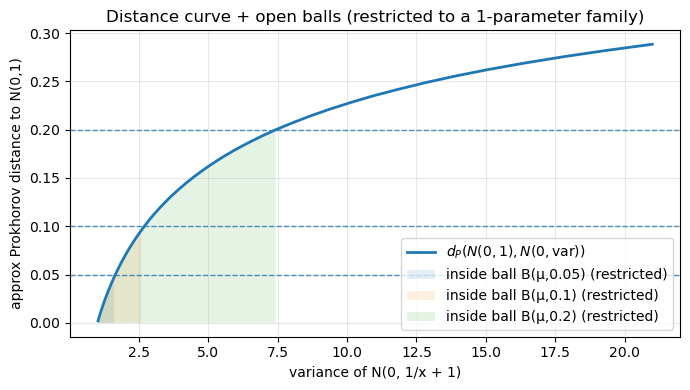

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def prokhorov_1d_from_cdfs(cdf_mu, cdf_nu, grid, tol=2e-4, eps_max=1.0):
    """
    Approximate Prokhorov distance on R (usual metric) using the Lévy-CDF criterion:
      d_P = inf{eps: for all x, F(x-eps)-eps <= G(x) <= F(x+eps)+eps}

    cdf_mu, cdf_nu: callables x -> CDF value in [0,1]
    grid: numpy array of x values where we enforce the inequalities
    """
    grid = np.asarray(grid)

    def condition_holds(eps):
        left  = cdf_mu(grid - eps) - eps
        mid   = cdf_nu(grid)
        right = cdf_mu(grid + eps) + eps
        return np.all(left <= mid) and np.all(mid <= right)

    lo, hi = 0.0, eps_max
    if not condition_holds(hi):
        return np.nan

    while hi - lo > tol:
        m = 0.5 * (lo + hi)
        if condition_holds(m):
            hi = m
        else:
            lo = m
    return hi


# --- Experiment: N(0,1) vs N(0, 1/x + 1) ---
sigma1 = 1.0
cdf1 = lambda t: norm.cdf(t, loc=0.0, scale=sigma1)

x_vals = np.geomspace(0.05, 50, 80)
var2_vals = 1.0 / x_vals + 1.0
sigma2_vals = np.sqrt(var2_vals)

sigma_max = float(np.max(np.maximum(sigma1, sigma2_vals)))
grid = np.linspace(-8*sigma_max, 8*sigma_max, 40001)

dP_vals = []
for s2 in sigma2_vals:
    cdf2 = lambda t, s=s2: norm.cdf(t, loc=0.0, scale=s)
    dP_vals.append(prokhorov_1d_from_cdfs(cdf1, cdf2, grid, tol=2e-4, eps_max=1.0))
dP_vals = np.array(dP_vals)

order = np.argsort(var2_vals)
var2_sorted = var2_vals[order]
dP_sorted = dP_vals[order]

# radii = "sizes of open balls" around μ=N(0,1)
radii = [0.05, 0.10, 0.20]

plt.figure(figsize=(7,4))
plt.plot(var2_sorted, dP_sorted, lw=2, label=r"$d_P(N(0,1), N(0,\mathrm{var}))$")

for r in radii:
    plt.axhline(r, ls="--", lw=1, alpha=0.8)
    inside = dP_sorted < r
    plt.fill_between(var2_sorted, 0, dP_sorted, where=inside, alpha=0.12,
                     label=f"inside ball B(μ,{r}) (restricted)")

plt.xlabel("variance of N(0, 1/x + 1)")
plt.ylabel("approx Prokhorov distance to N(0,1)")
plt.title("Distance curve + open balls (restricted to a 1-parameter family)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

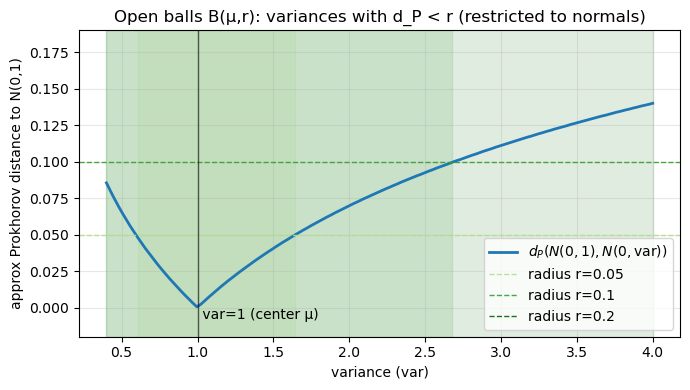

In [2]:
# center μ = N(0,1)
sigma1 = 1.0
cdf1 = lambda t: norm.cdf(t, loc=0.0, scale=sigma1)

# family ν_var = N(0,var)
var_grid = np.linspace(0.4, 4.0, 140)
sigma2_grid = np.sqrt(var_grid)

sigma_max = float(np.max(np.maximum(sigma1, sigma2_grid)))
xgrid = np.linspace(-8*sigma_max, 8*sigma_max, 40001)

dP = np.array([
    prokhorov_1d_from_cdfs(
        cdf1,
        (lambda t, s=s2: norm.cdf(t, loc=0.0, scale=s)),
        xgrid,
        tol=2e-4,
        eps_max=1.0
    )
    for s2 in sigma2_grid
])

radii = [0.05, 0.10, 0.20]

plt.figure(figsize=(7,4))
plt.plot(var_grid, dP, lw=2, color="C0",
         label=r"$d_P(N(0,1), N(0,\mathrm{var}))$")

# Shade "inside the ball" regions on the x-axis for each r
ymin, ymax = -0.02, float(np.nanmax(dP) + 0.05)
plt.ylim(ymin, ymax)

colors = ["#b2df8a", "#33a02c", "#006400"]  # light -> dark
for r, c in zip(radii, colors):
    inside = dP < r
    plt.axhline(r, ls="--", lw=1, color=c, alpha=0.9, label=f"radius r={r}")

    # shade contiguous segments where inside is True
    idx = np.where(inside)[0]
    if idx.size > 0:
        # find contiguous runs
        runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        for run in runs:
            left = var_grid[run[0]]
            right = var_grid[run[-1]]
            plt.axvspan(left, right, color=c, alpha=0.12)

plt.axvline(1.0, color="k", lw=1, alpha=0.6)
plt.text(1.0, ymin + 0.01, " var=1 (center μ)", ha="left", va="bottom")

plt.xlabel("variance (var)")
plt.ylabel("approx Prokhorov distance to N(0,1)")
plt.title("Open balls B(μ,r): variances with d_P < r (restricted to normals)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

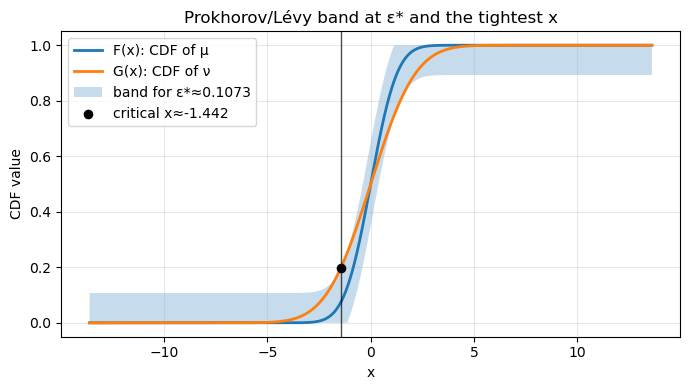

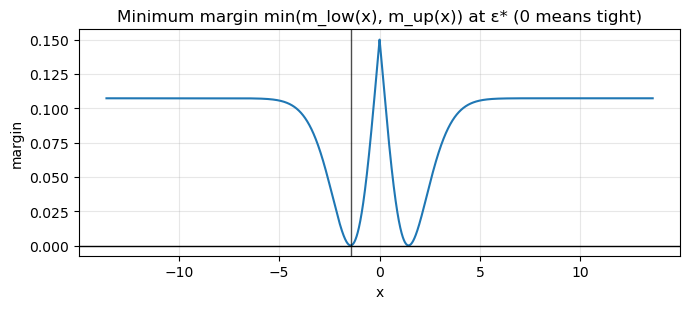

In [3]:
def band_and_critical_x_plot(sigma1=1.0, sigma2=1.7, tol=2e-4):
    F = lambda x: norm.cdf(x, loc=0.0, scale=sigma1)
    G = lambda x: norm.cdf(x, loc=0.0, scale=sigma2)

    # wide grid so we really approximate "for all x"
    sigma_max = max(sigma1, sigma2)
    x = np.linspace(-8*sigma_max, 8*sigma_max, 40001)

    eps_star = prokhorov_1d_from_cdfs(F, G, x, tol=tol, eps_max=1.0)

    # margins at eps_star
    lower = F(x - eps_star) - eps_star
    upper = F(x + eps_star) + eps_star
    Gx = G(x)

    m_low = Gx - lower
    m_up  = upper - Gx
    m_min = np.minimum(m_low, m_up)

    i_crit = int(np.argmin(m_min))
    x_crit = float(x[i_crit])

    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(x, F(x), lw=2, label="F(x): CDF of μ")
    plt.plot(x, Gx, lw=2, label="G(x): CDF of ν")

    # show the tolerance band
    plt.fill_between(x, np.clip(lower,0,1), np.clip(upper,0,1),
                     alpha=0.25,
                     label=fr"band for ε*≈{eps_star:.4f}")

    # mark the most critical x (tightest point)
    plt.axvline(x_crit, color="k", lw=1, alpha=0.7)
    plt.scatter([x_crit], [Gx[i_crit]], color="k", s=35, zorder=5,
                label=fr"critical x≈{x_crit:.3f}")

    plt.ylim(-0.05, 1.05)
    plt.xlabel("x")
    plt.ylabel("CDF value")
    plt.title("Prokhorov/Lévy band at ε* and the tightest x")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: a second plot showing how close we are to violating the constraint
    plt.figure(figsize=(7,3.2))
    plt.plot(x, m_min, lw=1.5)
    plt.axhline(0.0, color="k", lw=1)
    plt.axvline(x_crit, color="k", lw=1, alpha=0.7)
    plt.title("Minimum margin min(m_low(x), m_up(x)) at ε* (0 means tight)")
    plt.xlabel("x")
    plt.ylabel("margin")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

band_and_critical_x_plot(sigma1=1.0, sigma2=1.7, tol=2e-4)

If you only measured “vertical difference” between CDFs, e.g. the Kolmogorov distance

So the (d_K)-topology is the topology of uniform convergence of CDFs.

This is stronger than weak convergence in general.

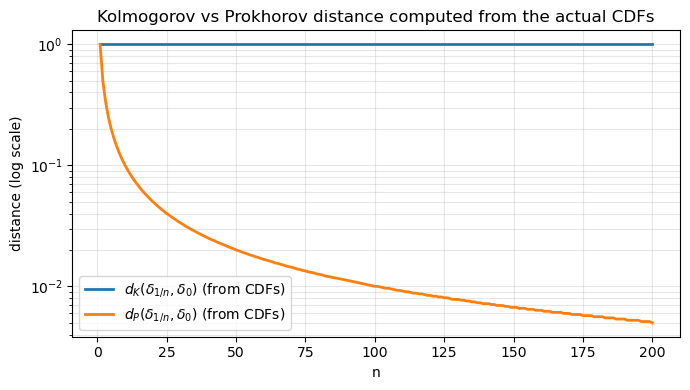

n=  1,  dK≈1.000000,  dP≈1.000000,  1/n=1.000000
n=  2,  dK≈1.000000,  dP≈0.500000,  1/n=0.500000
n=  5,  dK≈1.000000,  dP≈0.200073,  1/n=0.200000
n= 10,  dK≈1.000000,  dP≈0.100098,  1/n=0.100000
n= 50,  dK≈1.000000,  dP≈0.020020,  1/n=0.020000
n=100,  dK≈1.000000,  dP≈0.010010,  1/n=0.010000
n=200,  dK≈1.000000,  dP≈0.005005,  1/n=0.005000


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Generic distances from CDFs (1D) ----

def kolmogorov_from_cdfs(cdf_mu, cdf_nu, grid):
    """d_K = sup_x |F(x) - G(x)| approximated on a grid."""
    return float(np.max(np.abs(cdf_mu(grid) - cdf_nu(grid))))



# ---- CDF for a point mass δ_a ----
def cdf_delta(a):
    # returns a vectorized callable
    def F(x):
        x = np.asarray(x)
        return (x >= a).astype(float)
    return F


# ---- Demo: δ_{1/n} vs δ_0 using the CDF-based definitions ----

n = np.arange(1, 201)
a_vals = 1.0 / n

# grid that resolves the jump near 0 and spans the support
# make sure it includes points between 0 and min(a_vals)
grid = np.linspace(-0.5, 0.5, 20001)

F0 = cdf_delta(0.0)

dK_vals = []
dP_vals = []

for a in a_vals:
    Fa = cdf_delta(a)

    dK_vals.append(kolmogorov_from_cdfs(Fa, F0, grid))
    dP_vals.append(prokhorov_1d_from_cdfs(Fa, F0, grid, tol=2e-4, eps_max=1.0))

dK_vals = np.array(dK_vals)
dP_vals = np.array(dP_vals)

plt.figure(figsize=(7,4))
plt.plot(n, dK_vals, lw=2, label=r"$d_K(\delta_{1/n},\delta_0)$ (from CDFs)")
plt.plot(n, dP_vals, lw=2, label=r"$d_P(\delta_{1/n},\delta_0)$ (from CDFs)")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel("distance (log scale)")
plt.title("Kolmogorov vs Prokhorov distance computed from the actual CDFs")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

# Optional sanity check: print a few values
for k in [1, 2, 5, 10, 50, 100, 200]:
    print(f"n={k:3d},  dK≈{dK_vals[k-1]:.6f},  dP≈{dP_vals[k-1]:.6f},  1/n={1/k:.6f}")

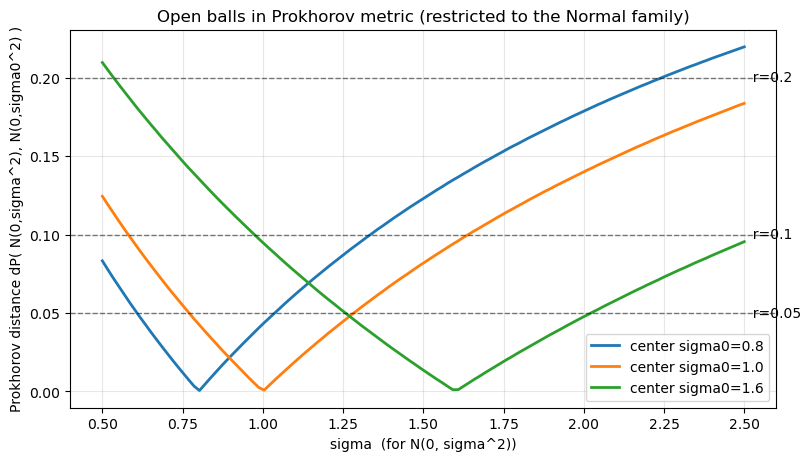

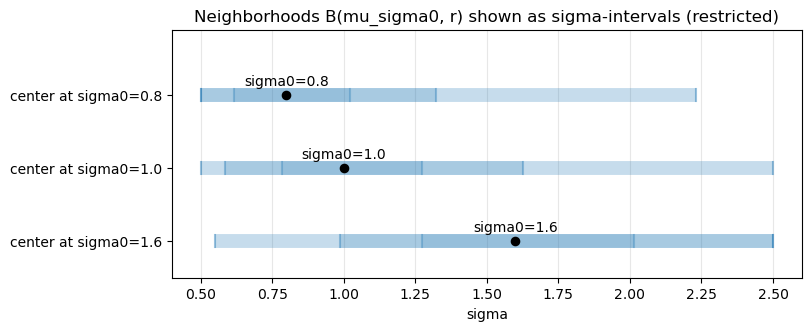

In [7]:
def dP_between_normals_sigma(sigma, sigma0, xgrid, tol=2e-4):
    F = lambda t: norm.cdf(t, loc=0.0, scale=sigma0)
    G = lambda t: norm.cdf(t, loc=0.0, scale=sigma)
    return prokhorov_1d_from_cdfs(F, G, xgrid, tol=tol, eps_max=1.0)


# ---- Choose sigma range and "centers" where we draw neighborhoods ----
sigma_grid = np.linspace(0.5, 2.5, 120)   # x-axis values: sigma
centers = [0.8, 1.0, 1.6]                 # points on x-axis we center balls at
radii = [0.05, 0.10, 0.20]                # radii r of open balls

# Grid on the real line big enough for the widest normal in play
sigma_max = float(np.max(np.r_[sigma_grid, centers]))
xgrid = np.linspace(-8*sigma_max, 8*sigma_max, 40001)

# Compute distance curves dP(N(0,sigma^2), N(0,sigma0^2)) for each center sigma0
curves = {}
for sigma0 in centers:
    curves[sigma0] = np.array([dP_between_normals_sigma(s, sigma0, xgrid) for s in sigma_grid])


# ---------------- Figure 1: distance vs sigma with horizontal r-lines ----------------
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

for sigma0 in centers:
    ax.plot(sigma_grid, curves[sigma0], lw=2, label=f"center sigma0={sigma0}")

for r in radii:
    ax.axhline(r, ls="--", lw=1, color="k", alpha=0.5)
    ax.text(sigma_grid[-1], r, f"  r={r}", va="center")

ax.set_xlabel("sigma  (for N(0, sigma^2))")
ax.set_ylabel("Prokhorov distance dP( N(0,sigma^2), N(0,sigma0^2) )")
ax.set_title("Open balls in Prokhorov metric (restricted to the Normal family)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


# ---------------- Figure 2: show the open-ball neighborhoods as sigma-intervals ----------------
fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)

y_levels = np.arange(len(centers), 0, -1)

for row, sigma0 in enumerate(centers):
    y = y_levels[row]
    ax.scatter([sigma0], [y], color="k", s=35, zorder=5)
    ax.text(sigma0, y+0.10, f"sigma0={sigma0}", ha="center", va="bottom")

    # For each r, shade where dP < r (restricted to this sigma grid)
    for r, alpha in zip(radii, [0.12, 0.18, 0.25]):  # bigger r => darker
        inside = curves[sigma0] < r
        idx = np.where(inside)[0]
        if idx.size == 0:
            continue
        runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        for run in runs:
            left = sigma_grid[run[0]]
            right = sigma_grid[run[-1]]
            ax.plot([left, right], [y, y], lw=10, solid_capstyle="butt",
                    alpha=alpha, color="C0")
            ax.plot([left, left], [y-0.08, y+0.08], color="C0", alpha=alpha+0.2)
            ax.plot([right, right], [y-0.08, y+0.08], color="C0", alpha=alpha+0.2)

ax.set_yticks(y_levels)
ax.set_yticklabels([f"center at sigma0={s0}" for s0 in centers])
ax.set_xlabel("sigma")
ax.set_title("Neighborhoods B(mu_sigma0, r) shown as sigma-intervals (restricted)")
ax.set_ylim(0.5, len(centers)+0.9)
ax.grid(True, axis="x", alpha=0.3)
plt.show()